Code for KSEA app

In [1]:
from typing import final

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from utils import *


from numpy.core.defchararray import upper
from setuptools.dist import sequence

In [2]:
df = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Handmade_Log2_FC_from_FGZC_log2FC0.5_nRep0_allPhosphoFound_True.xlsx")
df

,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF1,EGF2,EGF5,EGF10,EGF90,...,INS5_std,INS10_std,INS90_std,EGFnINS_full_std,EGFnINS_starve_std,EGFnINS1_std,EGFnINS2_std,EGFnINS5_std,EGFnINS10_std,EGFnINS90_std
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.750617,0,-0.075632,0.051413,0.553841,1.071310,0.614675,...,0.132813,0.082451,0.158647,0.240242,0.073607,0.213038,0.017743,0.137722,0.158750,0.203929
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,-0.726273,0,-0.103509,-0.389250,-0.566986,-0.520466,-0.750087,...,0.096032,0.092438,0.135065,0.190606,0.107901,0.087274,0.362086,0.085434,0.223696,0.084909
2,A0AVK6,E2F8,A0AVK6_660_664_1_1_S664~ENSSALsPNHR,-0.053965,0,-0.055564,-0.459914,-0.356172,-0.444423,-0.573204,...,0.044172,0.235586,0.347732,0.055253,0.015215,0.234871,0.148124,0.019416,0.167992,0.144247
3,A0FGR8,ESYT2,A0FGR8_736_748_1_1_S739~SSSsLLASPGHISVK,1.471331,0,1.676516,0.067826,0.366299,-0.140682,0.055614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A0FGR8,ESYT2,A0FGR8_736_748_1_1_S743~SSSSLLAsPGHISVK,0.197225,0,-0.073658,-0.266355,-0.434298,-0.500583,-0.091087,...,0.340014,0.291000,0.414456,0.357400,0.564312,0.836518,0.274693,0.579285,0.540069,0.643002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7059,Q9Y6X9,MORC2,Q9Y6X9_723_735_1_1_S725~KTEsPIKLSPATPSR,-0.319801,0,0.090892,-0.215619,-0.159935,-0.098344,-0.378652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7060,Q9Y6X9,MORC2,Q9Y6X9_723_735_2_2_S725S730~KTEsPIKLsPATPSR,-0.104364,0,-0.032278,-0.134237,-0.239501,-0.081470,-0.507507,...,0.009456,0.079574,0.075932,0.010742,0.125325,0.095246,0.307339,0.045301,0.359092,0.041603
7061,Q9Y6X9,MORC2,Q9Y6X9_739_743_1_1_S743~SVAVsDEEEVEEEAERR,-0.411413,0,-0.013029,-0.037583,-0.683015,-1.073718,-0.181425,...,0.119793,0.184561,0.132265,0.028969,0.122729,0.181125,0.055988,0.194354,0.210178,0.119344
7062,Q9Y6X9,MORC2,Q9Y6X9_739_743_2_2_S739S743~sVAVsDEEEVEEEAER,1.060594,0,-0.010913,0.251570,1.726090,2.320177,0.937512,...,0.189913,0.207445,0.178301,0.091927,0.317889,0.384452,0.211207,0.254863,0.307187,0.130371


In [29]:
columns = ["Protein", "Gene", "Peptide", "Residue.Both", "p", "FC"]
fc5 = pd.DataFrame(columns=columns)

def transform_string(s):
    return re.sub(r'(?<=\d)([STY])', r';\1', s)

for idx, row in df.iterrows():
    site = row["site"]
    info = site.split("_")[5]
    sequence = info.split("~")[-1].upper()
    residues = transform_string(info.split("~")[0])
    row_list = [row["protein_ID"], row["prot_name"], sequence, f"{residues}", "", row["EGF5"]]
    fc5.loc[len(fc5)] = row_list

    # fc5 = fc5.loc[[row_list], index = idx]
     
    
    
fc5.to_csv("Experiment/1_hTERT_HME1/Data/KSEA_app.csv", index=False)

In [30]:
pv_df = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/Renamed.xlsx", sheet_name="diff_exp_analysis_vs_starvation")
pv_df

,protein_ID,prot_name,IDcolumn,CON,REV,site,EGF10,EGF1,EGF2,EGF5,...,FDR_EGFnINS1,FDR_EGFnINS2,FDR_EGFnINS5,FDR_EGFnINS90,FDR_INS10,FDR_INS1,FDR_INS2,FDR_INS5,FDR_INS90,FDR_full
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2,False,False,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,1.071310,-0.075632,0.051413,0.553841,...,0.905741,0.217621,3.469526e-10,4.866379e-18,0.000143,0.786717,0.991555,0.000320,1.313045e-13,1.010236e-27
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2,False,False,A0A2R8Y4L2_260_271_1_0~NQGGYGGSSSSSSYGSGR,-0.181191,-0.055121,-0.172318,-0.206575,...,0.356162,0.846961,6.412688e-01,1.806562e-06,0.089553,0.375301,0.883893,0.345723,3.309695e-02,3.661412e-06
2,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2,False,False,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,-0.520466,-0.103509,-0.389250,-0.566986,...,0.092978,0.068232,3.523112e-03,2.706844e-06,0.001713,0.248862,0.162544,0.034000,1.040493e-03,2.656005e-06
3,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2,False,False,A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,-0.071683,0.099901,0.026794,-0.030970,...,0.731150,0.700846,6.136945e-01,4.722327e-01,0.936583,0.666638,0.943409,0.936723,6.807704e-01,2.370680e-01
4,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2,False,False,A0A2R8Y4L2_152_154_1_0~SGSGNFGGGR,0.296514,-0.045784,-0.057065,-0.181892,...,0.979194,0.931257,3.310392e-01,2.626061e-02,0.802508,0.957220,0.932037,0.774765,6.796439e-02,3.398565e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34997,Q9Y6Y0,IVNS1ABP,Q9Y6Y0,False,False,Q9Y6Y0_322_330_1_0~NSPQSSPTSTPK,0.130227,0.015958,0.080110,-0.013490,...,0.854629,0.453068,3.693374e-01,4.798816e-01,0.246901,0.697539,0.709894,0.748386,9.082090e-01,7.423666e-02
34998,Q9Y6Y0,IVNS1ABP,Q9Y6Y0,False,False,Q9Y6Y0_322_330_2_2_S322S325~NsPQsSPTSTPK,-0.489481,0.141716,-0.081345,-0.339977,...,0.376282,0.160700,2.537920e-01,2.689207e-01,0.597628,0.996477,0.805230,0.401615,9.114602e-01,2.097812e-01
34999,Q9Y6Y0,IVNS1ABP,Q9Y6Y0,False,False,Q9Y6Y0_336_356_1_0~SLSFEMQQDELIEKPMSPMQYAR,-0.104764,-0.094084,-0.149544,-0.103233,...,0.457757,0.827676,1.585905e-01,2.557543e-01,0.992172,0.910241,0.966369,0.759449,6.662907e-01,1.195186e-01
35000,Q9Y6Y8,SEC23IP,Q9Y6Y8,False,False,Q9Y6Y8_728_728_1_1_S728~GQEQsAQK,0.161375,-0.000013,-0.117576,0.133564,...,0.915157,0.881448,9.590686e-01,7.311165e-01,0.967659,0.920970,0.966762,0.188713,9.359625e-01,9.349252e-01


In [43]:
for index, row in df.iterrows():
    site = row["site"]
    p_value = pv_df.loc[pv_df["site"] == site]["pvalue_EGF5"].values[0]
    info = site.split("_")[5]
    sequence = info.split("~")[-1].upper()
    # print(p_value)
    fc5index = fc5.loc[fc5["Peptide"] == sequence].index[0]
    # 
    fc5.at[fc5index, "p"] = p_value


In [45]:
fc5.to_csv("Experiment/1_hTERT_HME1/Data/KSEA_app.csv", index=False)
fc5.to_excel("Experiment/1_hTERT_HME1/Data/KSEA_app.xlsx", index=False)



In [57]:
d = pd.read_excel("Experiment/1_hTERT_HME1/Data/KSEA_app.xlsx")
d.fillna(0, inplace=True)

In [59]:
for idx, row in d.iterrows():
    # print(row["p"])
    if row["p"] == 0:
        # print("drop")
        d.drop(idx, inplace=True)

In [17]:
d.to_csv("Experiment/1_hTERT_HME1/Data/KSEA_app_test.csv", index=False)

NameError: name 'd' is not defined

In [18]:
a = df.loc[df['prot_name'] == "HNRNPA1L3"].copy()
a

,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF1,EGF2,EGF5,EGF10,EGF90,...,INS5_std,INS10_std,INS90_std,EGFnINS_full_std,EGFnINS_starve_std,EGFnINS1_std,EGFnINS2_std,EGFnINS5_std,EGFnINS10_std,EGFnINS90_std
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.750617,0,-0.075632,0.051413,0.553841,1.071310,0.614675,...,0.132813,0.082451,0.158647,0.240242,0.073607,0.213038,0.017743,0.137722,0.158750,0.203929
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,-0.726273,0,-0.103509,-0.389250,-0.566986,-0.520466,-0.750087,...,0.096032,0.092438,0.135065,0.190606,0.107901,0.087274,0.362086,0.085434,0.223696,0.084909


In [23]:
b = f"{a.prot_name[0]}_{a.protein_ID[0]}"
print(b)

HNRNPA1L3_A0A2R8Y4L2


In [ ]:
###################
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Example function that plots data for a single row
def plot_row(ax, row):
    """Plots data from a single row onto the provided Axes object."""
    x = np.linspace(0, 10, 100)
    y = np.sin(x) * row['amplitude']  # Example function using row data
    ax.plot(x, y, label=f"Row {row.name}")
    ax.set_title(f"Plot {row.name}")
    ax.legend()


# Function to iterate through the DataFrame and create subplots
def plot_all_rows(df):
    """Creates a subplot for each row in the dataframe."""
    n_rows = len(df)
    cols = 3  # Number of columns per row
    rows = -(-n_rows // cols)  # Ceiling division for number of rows

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))

    # Flatten axes array if there's more than one row
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, (idx, row) in enumerate(df.iterrows()):
        plot_row(axes[i], row)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Example DataFrame
df = pd.DataFrame({'amplitude': np.random.rand(7) * 10})  # 7 rows of random amplitudes
plot_all_rows(df)


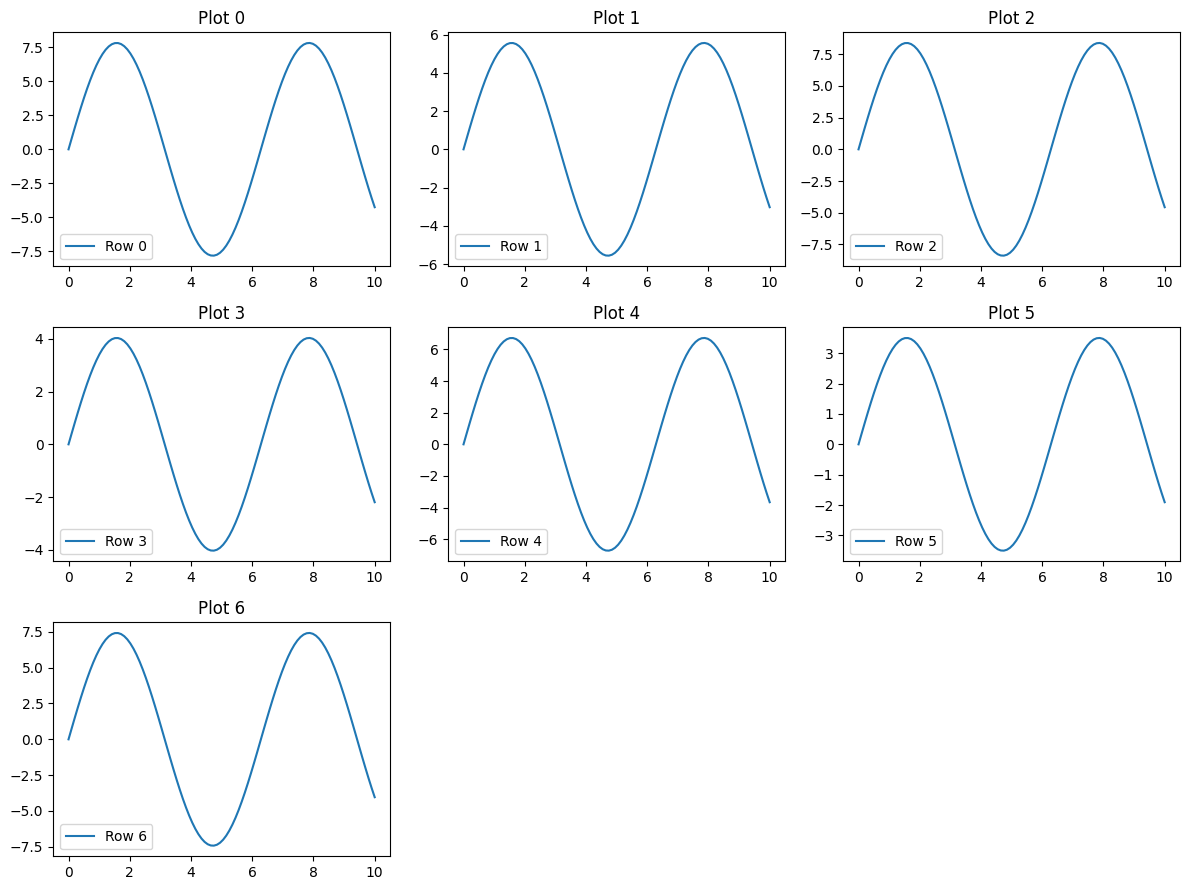

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

# Example function that plots data for a single row
def plot_row(ax, row):
    """Plots data from a single row onto the provided Axes object."""
    x = np.linspace(0, 10, 100)
    y = np.sin(x) * row['amplitude']  # Example function using row data
    ax.plot(x, y, label=f"Row {row.name}")
    ax.set_title(f"Plot {row.name}")
    ax.legend()

# Function to iterate through the DataFrame and create subplots
def plot_all_rows(df):
    """Creates a subplot for each row in the dataframe with dynamic grid sizing."""
    n_rows = len(df)
    cols = math.ceil(math.sqrt(n_rows))  # Rounded-up square root for columns
    rows = math.ceil(n_rows / cols)  # Ceiling division to get enough rows
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))

    # Flatten axes array if there's more than one row
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, (idx, row) in enumerate(df.iterrows()):
        plot_row(axes[i], row)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Example DataFrame with random amplitudes
df = pd.DataFrame({'amplitude': np.random.rand(7) * 10})  # 7 rows
plot_all_rows(df)

## trying out PCA


In [6]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# importing or loading the dataset
dataset = pd.read_csv('wine.csv')
dataset

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [12]:
# distributing the dataset into two components X and Y
X = dataset.iloc[:, 0:13].values
y = dataset.iloc[:, 13].values
print(y)
X

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [17]:
# Splitting the X and Y into the
# Training set and Testing set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
X_train

(142, 13) (36, 13) (142,) (36,)


array([[1.369e+01, 3.260e+00, 2.540e+00, ..., 9.600e-01, 1.820e+00,
        6.800e+02],
       [1.269e+01, 1.530e+00, 2.260e+00, ..., 9.600e-01, 2.060e+00,
        4.950e+02],
       [1.162e+01, 1.990e+00, 2.280e+00, ..., 1.160e+00, 2.960e+00,
        3.450e+02],
       ...,
       [1.242e+01, 1.610e+00, 2.190e+00, ..., 1.060e+00, 2.960e+00,
        3.450e+02],
       [1.390e+01, 1.680e+00, 2.120e+00, ..., 9.100e-01, 3.330e+00,
        9.850e+02],
       [1.416e+01, 2.510e+00, 2.480e+00, ..., 6.200e-01, 1.710e+00,
        6.600e+02]])

In [18]:
# performing preprocessing part
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_train

array([[ 0.87668336,  0.79842885,  0.64412971, ...,  0.0290166 ,
        -1.06412236, -0.2059076 ],
       [-0.36659076, -0.7581304 , -0.39779858, ...,  0.0290166 ,
        -0.73083231, -0.81704676],
       [-1.69689407, -0.34424759, -0.32337513, ...,  0.90197362,
         0.51900537, -1.31256499],
       ...,
       [-0.70227477, -0.68615078, -0.65828065, ...,  0.46549511,
         0.51900537, -1.31256499],
       [ 1.13777093, -0.62316862, -0.91876272, ..., -0.18922266,
         1.03282752,  0.80164614],
       [ 1.4610222 ,  0.12361993,  0.42085937, ..., -1.45501034,
        -1.2168803 , -0.2719767 ]])

In [22]:
# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)
X_train

[0.65627164 0.34372836]


array([[-2.17884511e+00, -1.07218467e+00],
       [-1.80819239e+00,  1.57822344e+00],
       [ 1.09829474e+00,  2.22124345e+00],
       [-2.55584748e+00, -1.66210369e+00],
       [ 1.85698063e+00,  2.41573166e-01],
       [ 2.58288576e+00, -1.37668170e+00],
       [ 8.72876119e-01,  2.25618512e+00],
       [-4.18384029e-01,  2.35415681e+00],
       [-3.04977245e-01,  2.27659433e+00],
       [ 2.14082532e+00, -1.10052871e+00],
       [-2.98136465e+00, -2.47159183e-01],
       [ 1.96188242e+00,  1.25407738e+00],
       [-2.16177795e+00, -9.75966550e-01],
       [ 2.21976084e+00, -2.39507167e+00],
       [-2.30179529e+00, -2.05791962e-01],
       [-3.00953827e+00, -2.79141212e-01],
       [ 2.63443473e+00, -8.68313119e-01],
       [-1.09219965e+00, -3.53906625e+00],
       [ 2.62578435e+00, -2.96852840e-03],
       [ 1.98077342e-01,  2.29193443e+00],
       [-2.67442753e+00, -2.58800132e+00],
       [-2.54763698e+00, -4.52703891e-01],
       [ 1.77416736e+00,  8.43586940e-01],
       [-2.

In [25]:
# Fitting Logistic Regression To the training set
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)
classifier.coef_

array([[ 1.05496534, -0.75879629],
       [ 0.22130117,  1.86553335],
       [-1.27626651, -1.10673706]])

In [27]:
# Predicting the test set result using
# predict function under LogisticRegression
y_pred = classifier.predict(X_test)
y_pred

array([1, 3, 2, 1, 2, 1, 1, 3, 2, 2, 3, 3, 1, 2, 3, 2, 1, 1, 2, 1, 2, 1,
       1, 2, 2, 2, 2, 2, 2, 3, 1, 1, 2, 1, 1, 1])

In [28]:
# making confusion matrix between
#  test set of Y and predicted value.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[14,  0,  0],
       [ 1, 15,  0],
       [ 0,  0,  6]])

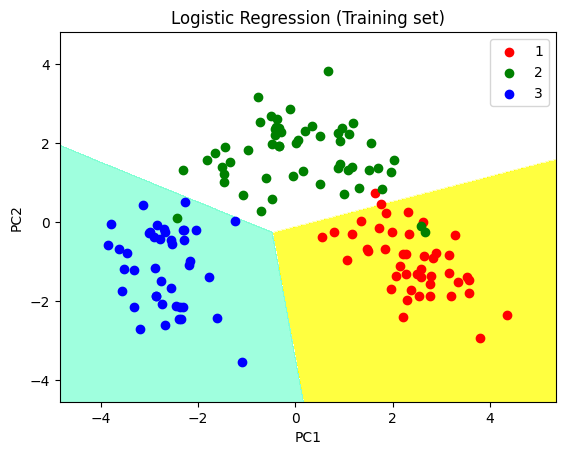

In [29]:
# Predicting the training set
# result through scatter plot
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1,
                               stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1,
                               stop=X_set[:, 1].max() + 1, step=0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(),
                                                  X2.ravel()]).T).reshape(X1.shape), alpha=0.75,
             cmap=ListedColormap(('yellow', 'white', 'aquamarine')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color=ListedColormap(('red', 'green', 'blue'))(i), label=j)

plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')  # for Xlabel
plt.ylabel('PC2')  # for Ylabel
plt.legend()  # to show legend

# show scatter plot
plt.show()

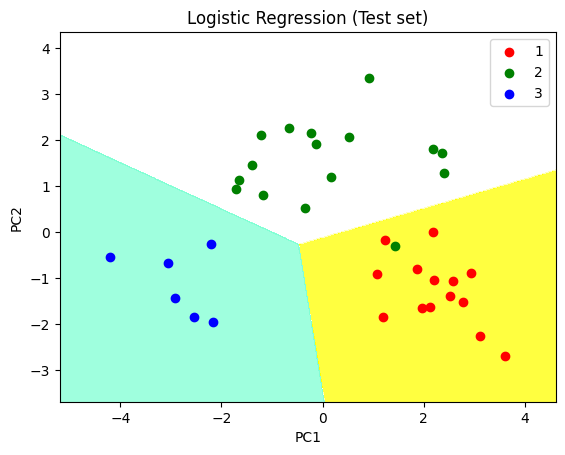

In [30]:
# Visualising the Test set results through scatter plot
X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1,
                               stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1,
                               stop=X_set[:, 1].max() + 1, step=0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(),
                                                  X2.ravel()]).T).reshape(X1.shape), alpha=0.75,
             cmap=ListedColormap(('yellow', 'white', 'aquamarine')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color=ListedColormap(('red', 'green', 'blue'))(i), label=j)

# title for scatter plot
plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')  # for Xlabel
plt.ylabel('PC2')  # for Ylabel
plt.legend()

# show scatter plot
plt.show()

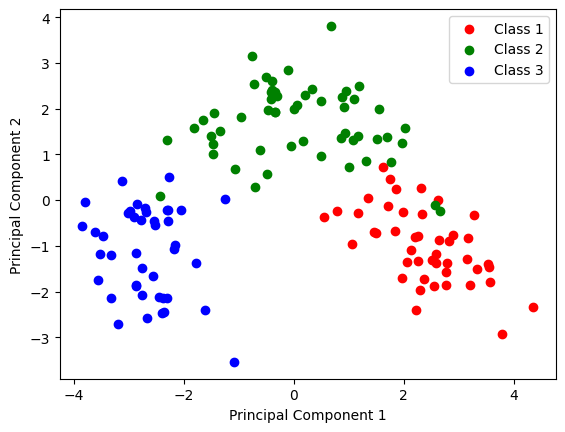

In [31]:
# plot the first two principal components with labels
colors = ["r", "g", "b"]
labels = ["Class 1", "Class 2", "Class 3"]
for i, color, label in zip(np.unique(y), colors, labels):
    plt.scatter(X_train[y_train == i, 0], X_train[y_train == i, 1], color=color, label=label)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

For the PCA the X dataset is the timepoints and the Y would be numbers from 1 to 64 based on the condition and replicate

In [2]:
df = pd.read_excel('Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff_renamed.xlsx')

In [3]:
df

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS_starve,CV_raw_EGFnINS_2,CV_raw_EGFnINS_5,CV_raw_EGFnINS_10,CV_raw_EGFnINS_15,CV_raw_EGFnINS_90,CV_raw_All,difference_EGF_vs_EGFnINS_,difference_INS_vs_EGFnINS_,difference_geometric_mean
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.346090,0.644357,0.274540,0.420597
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,18.757996,26.165101,1.230777,12.588830,22.938866,25.170515,50.670048,2.434020,1.123635,1.653768
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,11.127109,2.641531,3.917276,5.877727,6.619161,2.665032,10.012151,0.255705,0.459264,0.342689
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.437045,0.277106,0.671679,0.431424
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,2.917751,8.674894,9.209089,5.233678,18.339542,5.388291,13.267868,0.295146,0.411714,0.348591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.475756,0.105879,0.085024,0.094880
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.985616,0.139221,0.087091,0.110113
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.585989,0.450723,0.196474,0.297582
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.384036,0.196891,0.163787,0.179578


In [7]:
subset = df[["protein_Id", "protein_name", "site", "difference_EGF_vs_EGFnINS_", "difference_INS_vs_EGFnINS_", "difference_geometric_mean"]]
subset

,protein_Id,protein_name,site,difference_EGF_vs_EGFnINS_,difference_INS_vs_EGFnINS_,difference_geometric_mean
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_197_199_1_0~SGSGNFGGGR,0.644357,0.274540,0.420597
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_197_199_1_1_S199~SGsGNFGGGR,2.434020,1.123635,1.653768
2,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_2_6_1_1_S6~SKSEsPKEPEQLR,0.255705,0.459264,0.342689
3,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_2_6_2_2_S2S4~sKsESPK,0.277106,0.671679,0.431424
4,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_305_316_1_0~NQGGYGGSSSSSSYGSGR;NQGG...,0.295146,0.411714,0.348591
...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,rev_Q5VWT5_303_307_2_2_T303T307~GALMNRRGtHVNtMQIK,0.105879,0.085024,0.094880
50010,rev_Q8N6M0,0,rev_Q8N6M0_135_141_1_1_S141~LQDEIAKYMCHGDsPIQK,0.139221,0.087091,0.110113
50011,rev_Q96M83,0,rev_Q96M83_505_505_1_1_T505~ERGPtIKK,0.450723,0.196474,0.297582
50012,rev_Q9ULL1,0,rev_Q9ULL1_1366_1376_2_0~SSASSSTSGFSVPR,0.196891,0.163787,0.179578


In [14]:
ordered = subset.sort_values(by="difference_geometric_mean", ascending=False)
ordered.head()

,protein_Id,protein_name,site,difference_EGF_vs_EGFnINS_,difference_INS_vs_EGFnINS_,difference_geometric_mean
7588,P17480,UBTF,P17480_193_208_1_1_T201~SDIPEKPKtPQQLWYTHEK,8.378787,6.815808,7.556997
59,A0MZ66,SHTN1,A0MZ66_381_386_1_1_S384~SHPsGSGAK,8.579678,6.102769,7.236007
48439,rev_Q9NXS3,0,rev_Q9NXS3_335_335_1_1_Y335~DDRILHNAEyLR,2.113316,13.691091,5.378997
17676,Q13480,GAB1,Q13480_627_638_2_2_Y627T638~GDKQVEyLDLDLDSGKStPPR,1.737590,15.776583,5.235765
5184,O95817,BAG3,O95817_171_191_1_0~SQSPAASDCSSSSSSASLPSSGR,3.642863,7.127496,5.095536


In [15]:
print(ordered.protein_name.head(50).unique())

['UBTF' 'SHTN1' 0 'GAB1' 'BAG3' 'PXN' 'GEMIN8' 'ITPR3' 'CTDSPL2' 'PML'
 'RABL6' 'STAM2' 'HGS' 'PPP1R37' 'IRS1' 'NAA38' 'PLEK2' 'COL17A1' 'KRT1'
 'UBR4' 'FHIP1B' 'PRRC2C' 'ARPP19' 'CIC' 'MAPRE1' 'KRT13' 'FAM83H' 'PPIG'
 'SYNM' 'NFKB2' 'RAD23B' 'NCAPD2' 'BMP2K' 'LAD1' 'ZNF609' 'DSP' 'HDLBP'
 'SOS1' 'PCM1' 'JSRP1' 'ZNF462' 'USP37' 'ERBIN' 'RECQL4' 'POTEA']


In [5]:
prots = ['P17480', 'A0MZ66']
uniprot_links_for(prots)